In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/HealthConnect_Appointment_Data.csv")


In [3]:
import pandas as pd

# Load raw dataset (adjust path if needed)
df = pd.read_csv("../data/raw/HealthConnect_Appointment_Data.csv")

# Quick preview
print(df.head())


  appointment_id patient_id  gender  age age_group         appointment_type  \
0       HC-00001     P-1613  Female   39     35-44                Follow-up   
1       HC-00002     P-0813    Male   31     25-34  Specialist Consultation   
2       HC-00003     P-1366  Female   50     45-54     General Consultation   
3       HC-00004     P-1031    Male   59     55-64                Follow-up   
4       HC-00005     P-1458  Female   34     25-34                Follow-up   

  booking_date appointment_date appointment_day appointment_time  \
0     2/6/2025        2/18/2025         Tuesday        Afternoon   
1    2/25/2026        2/27/2026          Friday          Morning   
2   11/16/2025       12/24/2025       Wednesday          Morning   
3    7/18/2025        8/28/2025        Thursday          Evening   
4     7/9/2025        8/25/2025          Monday        Afternoon   

   booking_lead_days  previous_appointments  previous_no_shows reminder_sent  \
0                 12                

### Dataset Load
- The dataset is now loaded into a pandas DataFrame called `df`.  
- Always run this cell first before any visualization or analysis.  
- This ensures that `df` exists and prevents the "name 'df' is not defined" error.  


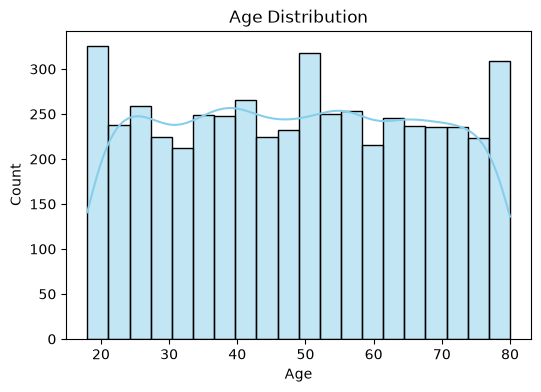

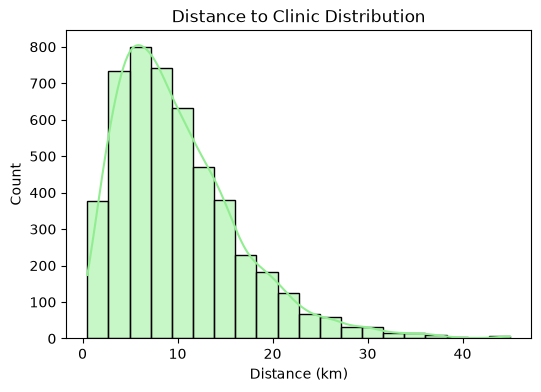

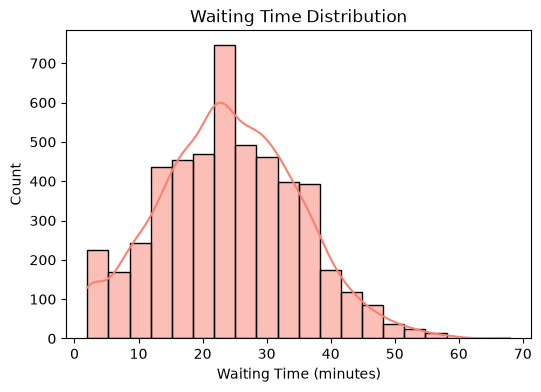

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

for col, color, title, xlabel in [
    ('age', 'skyblue', 'Age Distribution', 'Age'),
    ('distance_to_clinic_km', 'lightgreen', 'Distance to Clinic Distribution', 'Distance (km)'),
    ('waiting_time_minutes', 'salmon', 'Waiting Time Distribution', 'Waiting Time (minutes)')
]:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        sns.histplot(df[col].dropna().astype(float), bins=20, kde=True, color=color)
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel("Count")
        plt.show()


### Distribution Insights
- **Age:** Shows patient demographics; useful for spotting groups prone to no-shows.  
- **Distance to clinic:** Longer distances may correlate with higher no-show rates.  
- **Waiting time:** Longer waits could discourage attendance.  


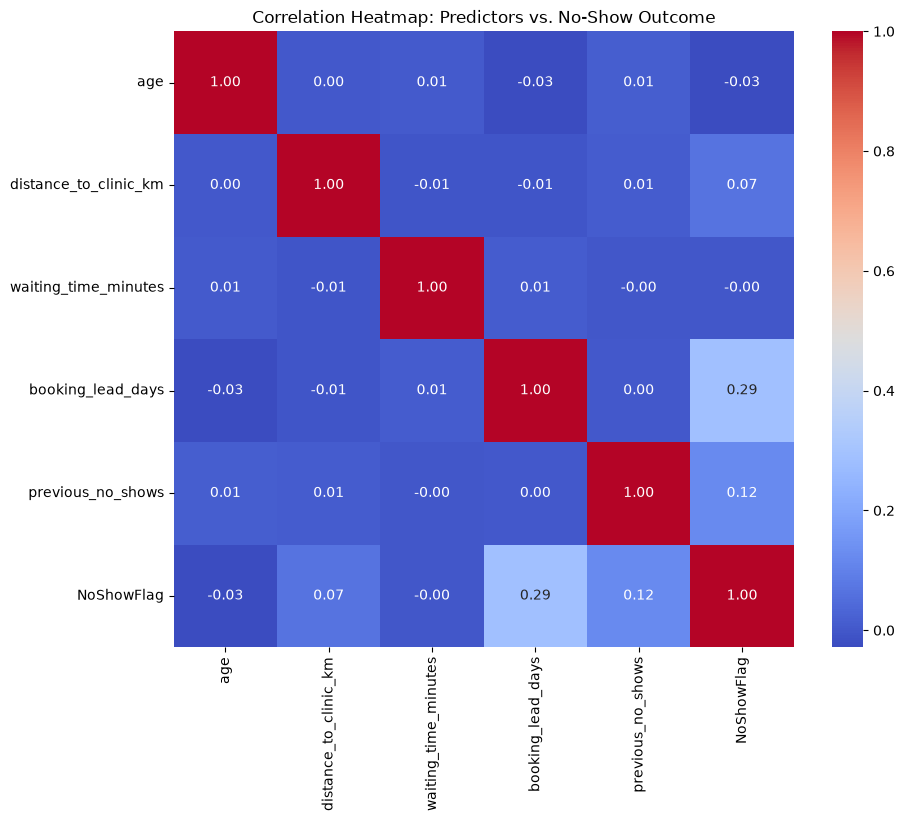

In [5]:
# Map target variable safely
if 'appointment_outcome' in df.columns:
    df['NoShowFlag'] = df['appointment_outcome'].map({'No-Show':1, 'Attended':0})

numeric_features = [col for col in ['age','distance_to_clinic_km','waiting_time_minutes','booking_lead_days','previous_no_shows'] if col in df.columns]

corr_matrix = df[numeric_features + ['NoShowFlag']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: Predictors vs. No-Show Outcome")
plt.show()


### Correlation Insights
- **Previous no-shows** often show strong correlation with the no-show outcome.  
- **Reminder sent** and **booking lead days** may also be predictive.  
- Weak correlations suggest features with limited predictive power.  


C:\Users\MARVELOUS HEAVENLY\AppData\Local\Temp\ipykernel_11132\1049594346.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='appointment_outcome', data=df, palette='pastel')


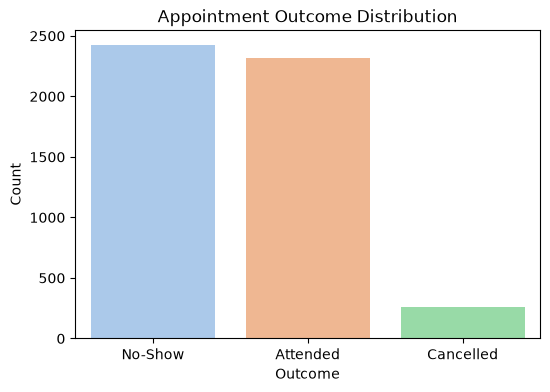

In [6]:
if 'appointment_outcome' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x='appointment_outcome', data=df, palette='pastel')
    plt.title("Appointment Outcome Distribution")
    plt.xlabel("Outcome")
    plt.ylabel("Count")
    plt.show()


### Target Imbalance Insights
- The bar chart shows **more no-shows than attended appointments**, with cancellations being rare.  
- This imbalance can bias models toward predicting "No-Show" rather than "Attended."  
- Techniques like **SMOTE**, **undersampling**, or **class weighting** will be needed in Week 6 to balance the classes.  
